# CS5489 - Machine Learning
# Lecture 6b - Regularization
### Dept. of Computer Science, City University of Hong Kong

# Outline
- Convolutional neural network (CNN)
- **Regularization**

In [1]:
# setup
import os
%matplotlib inline
# matplotlib.use('Agg')
import matplotlib_inline   # setup output image format
matplotlib_inline.backend_inline.set_matplotlib_formats('retina')
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 100  # display larger images
import matplotlib
import numpy as np
from numpy import *
from sklearn import *
from scipy import stats
from scipy import signal
from prettytable import PrettyTable

rbow = plt.get_cmap('rainbow')

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader, TensorDataset, Dataset
from torch.utils.tensorboard import SummaryWriter
import struct
import sys
print(f"Python: {sys.version} PyTorch: {torch.__version__}")

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Python: 3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:09:02) [GCC 11.2.0] PyTorch: 2.8.0+cu129
Using device: cuda


In [3]:
def plot_history(history): 
    fig, ax1 = plt.subplots()
    
    ax1.plot(history['train_loss'], 'r', label="training loss ({:.6f})".format(history['train_loss'][-1]))
    ax1.plot(history['val_loss'], 'r--', label="validation loss ({:.6f})".format(history['val_loss'][-1]))
    ax1.grid(True)
    ax1.set_xlabel('iteration')
    ax1.legend(loc="best", fontsize=9)    
    ax1.set_ylabel('loss', color='r')
    ax1.tick_params('y', colors='r')

    if 'train_accuracy' in history:
        ax2 = ax1.twinx()

        ax2.plot(history['train_accuracy'], 'b', label="training acc ({:.4f})".format(history['train_accuracy'][-1]))
        ax2.plot(history['val_accuracy'], 'b--', label="validation acc ({:.4f})".format(history['val_accuracy'][-1]))

        ax2.legend(loc="best", fontsize=9)
        ax2.set_ylabel('acc', color='b')        
        ax2.tick_params('y', colors='b')
    plt.show() 

In [4]:
def show_imgs(W_list, nc=10, highlight_green=None, highlight_red=None, titles=None):
    nfilter = len(W_list)
    nr = (nfilter - 1) // nc + 1
    for i in range(nr):
        for j in range(nc):
            idx = i * nc + j
            if idx == nfilter:
                break
            plt.subplot(nr, nc, idx + 1)
            cur_W = W_list[idx]
            plt.imshow(cur_W,cmap='gray', interpolation='nearest')  
            if titles is not None:
                plt.title(titles % idx)
            
            if ((highlight_green is not None) and highlight_green[idx]) or \
               ((highlight_red is not None) and highlight_red[idx]): 
                ax = plt.gca()
                if highlight_green[idx]:
                    mycol = '#00FF00'
                else:
                    mycol = 'r'
                for S in ['bottom', 'top', 'right', 'left']:
                    ax.spines[S].set_color(mycol)
                    ax.spines[S].set_lw(2.0)
                ax.xaxis.set_ticks_position('none')               
                ax.yaxis.set_ticks_position('none')
                ax.set_xticks([])
                ax.set_yticks([])
            else:
                plt.gca().set_axis_off()

In [5]:
def read_32int(f):
    return struct.unpack('>I', f.read(4))[0]
def read_img(img_path):
    with open(img_path, 'rb') as f:
        magic_num = read_32int(f)
        num_image = read_32int(f)
        n_row = read_32int(f)
        n_col = read_32int(f)
        #print 'num_image = {}; n_row = {}; n_col = {}'.format(num_image, n_row, n_col)
        res = []
        npixel = n_row * n_col
        res_arr = fromfile(f, dtype='B')
        res_arr = res_arr.reshape((num_image, n_row, n_col), order='C')
        #print 'image data shape = {}'.format(res_arr.shape)
        return num_image, n_row, n_col, res_arr    
def read_label(label_path):
    with open(label_path, 'rb') as f:
        magic_num = read_32int(f)
        num_label = read_32int(f)
        #print 'num_label = {}'.format(num_label)
        res_arr = fromfile(f, dtype='B')
        #print res_arr.shape
        #res_arr = res_arr.reshape((num_label, 1))
        res_arr = res_arr.ravel()
        #print 'label data shape = {}'.format(res_arr.shape)
        return num_label, res_arr

In [6]:
n_train, nrow, ncol, trainimg = read_img('data/train-images.idx3-ubyte')
_, trainY = read_label('data/train-labels.idx1-ubyte')
n_test, _, _, testimg = read_img('data/t10k-images.idx3-ubyte')
_, testY = read_label('data/t10k-labels.idx1-ubyte')

# for demonstration we only use 10% of the training data
sample_index = range(0, trainimg.shape[0], 10)
trainimg  = trainimg[sample_index]
trainY    = trainY[sample_index]
print(trainimg.shape)
print(trainY.shape)
print(testimg.shape)
print(testY.shape)

(6000, 28, 28)
(6000,)
(10000, 28, 28)
(10000,)


In [7]:
# Convert to PyTorch tensors and scale to 0-1
trainI = torch.from_numpy(trainimg.reshape((6000, 1, 28, 28)) / 255.0).float()
testI = torch.from_numpy(testimg.reshape((10000, 1, 28, 28)) / 255.0).float()

print(trainI.shape)
print(testI.shape)

torch.Size([6000, 1, 28, 28])
torch.Size([10000, 1, 28, 28])


In [8]:
# Generate fixed validation set
from sklearn.model_selection import train_test_split

vtrainI_np, validI_np, vtrainY_np, validY_np = train_test_split(
    trainI.numpy(), trainY, 
    train_size=0.9, test_size=0.1, random_state=4487
)

vtrainI = torch.from_numpy(vtrainI_np).float()
validI = torch.from_numpy(validI_np).float()
vtrainY = torch.from_numpy(vtrainY_np).long()
validY = torch.from_numpy(validY_np).long()

print(f"Training set: {vtrainI.shape}, {vtrainY.shape}")
print(f"Validation set: {validI.shape}, {validY.shape}")

cid, cfreq = vtrainY.unique(return_counts=True)

print(f"Training set Distribution:", cfreq.numpy().tolist())

Training set: torch.Size([5400, 1, 28, 28]), torch.Size([5400])
Validation set: torch.Size([600, 1, 28, 28]), torch.Size([600])
Training set Distribution: [491, 599, 554, 556, 513, 518, 567, 584, 496, 522]


# Regularization with L2-norm
- One way to regularize the network is to add an L2-norm penalty on the weights
  - Add a penalty term to the loss function
    - larger weights have higher penalty
    - $\hat{L} = L + \lambda\frac{1}{2}||\mathbf{w}||^2$

- Taking the gradient of $\hat{L}$,
  - $\frac{d\hat{L}}{d\mathbf{w}} = \frac{dL}{d\mathbf{w}} + \lambda \mathbf{w}$
- Applying gradient descent
  - $\mathbf{w} \leftarrow \mathbf{w} - \eta \frac{d\hat{L}}{d\mathbf{w}}$
  - $\mathbf{w} \leftarrow \mathbf{w} - \eta (\frac{dL}{d\mathbf{w}} + \lambda \mathbf{w})$
  - $\mathbf{w} \leftarrow (1-\eta\lambda)\mathbf{w} - \eta \frac{dL}{d\mathbf{w}}$
- the weights shrink by $(1-\eta\lambda)$ in each iteration of gradient descent.
  - prevents the $\mathbf{w}$ from getting too large.
  - Sometimes this is called **weight-decay** regularization.
    

- The optimal solution is an equilibrium point between L2-norm (dashed-line) and the loss (solid-line).
  - $\lambda\mathbf{w} = -\frac{dL}{d\mathbf{w}}$.
<center><img src="imgs/weightdecay.png" width=300></center>

# Example: L2 regularization
- Apply L2 regularization on all layers.
  - `kernel_regularizer` keyword

In [9]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5, stride=2, padding=2)
        self.conv2 = nn.Conv2d(10, 40, kernel_size=5, stride=2, padding=2)
        self.conv3 = nn.Conv2d(40, 80, kernel_size=5, stride=1, padding=2)
        self.fc1 = nn.Linear(80 * 7 * 7, 50)  # Adjusted based on input size and strides
        self.fc2 = nn.Linear(50, 10)
        
        self.relu = nn.ReLU()
        self.softmax = nn.Softmax(dim=1)
        
    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.relu(self.conv3(x))
        x = x.view(x.size(0), -1)  # Flatten
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x
    
    def l2_regularization(self):
        return 0.0

class CNNWithL2(CNN):
    def __init__(self, weight_decay=0.0001):
        super(CNNWithL2, self).__init__()
        self.weight_decay = weight_decay

    def l2_regularization(self):
        l2_reg = torch.tensor(0.).to(device)
        for param in self.parameters():
            l2_reg += torch.norm(param, p=2)
        return self.weight_decay * 0.5 * l2_reg

In [10]:
# Early stopping implementation
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.0001, verbose=1):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_accuracy = 0.0
        self.early_stop = False
        self.verbose = verbose
        
    def __call__(self, current_accuracy):
        if current_accuracy - self.best_accuracy > self.min_delta:
            self.best_accuracy = current_accuracy
            self.counter = 0
        else:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        return self.early_stop

In [11]:
# Model Parameter Summarization
def summarize_layer_parameters(model):
    """
    Summarizes the number of parameters in each layer of a PyTorch model.
    """
    trainable_table = PrettyTable(["Module Name", "Parameters"])
    untrainable_table = PrettyTable(["Module Name", "Parameters"])
    total_params = {'train':0,'untrain':0}
    for name, parameter in model.named_parameters():
        if parameter.requires_grad:  # Only count trainable parameters
            params = parameter.numel()
            trainable_table.add_row([name, params])
            total_params['train'] += params
        else:  # Only count untrainable parameters
            params = parameter.numel()
            untrainable_table.add_row([name, params])
            total_params['untrain'] += params
        
    print(trainable_table)
    print(f"\nTotal Trainable Parameters: {total_params['train']}")
    if total_params['untrain'] > 0:
        print(untrainable_table)
    print(f"\nTotal Un-Trainable Parameters: {total_params['untrain']}")

In [12]:
# Model Evaluation
def evaluate_model(model, eval_loader, criterion=None):
    model.eval()
    eval_correct = 0
    eval_total = 0
    eval_loss = 0.0
    
    with torch.no_grad():
        for data, target in eval_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            _, predicted = torch.max(output.data, 1)
            eval_total += target.size(0)
            eval_correct += (predicted == target).sum().item()

            if criterion is not None:
                loss = criterion(output, target)
                eval_loss += loss.item()
    
    eval_accuracy = 100 * eval_correct / eval_total
    avg_eval_loss = eval_loss / len(eval_loader)

    return eval_accuracy if criterion is None else (eval_accuracy, avg_eval_loss)


# Model Training
def train_model(model, train_loader, valid_loader, criterion, optimizer, epochs=100, patience=5, writer='runs/cnn'):
    history = {
        'train_loss': [], 'val_loss': [],
        'train_accuracy': [], 'val_accuracy': []
    }
    early_stopping = EarlyStopping(patience=patience)
    ckpt_path = os.path.join(os.path.abspath('.'), writer, 'best_model.pth')
    writer = SummaryWriter(writer)
    
    # best_val_loss = float('inf')
    # patience_counter = 0
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            output = model(data)
            
            # loss = criterion(output, torch.nn.functional.one_hot(target, num_classes=10).float()) also works
            loss = criterion(output, target) + model.l2_regularization()
            
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(output.data, 1)
            train_total += target.size(0)
            train_correct += (predicted == target).sum().item()
        
        train_accuracy = 100 * train_correct / train_total
        avg_train_loss = train_loss / len(train_loader)
        
        # Validation phase
        val_accuracy, avg_val_loss = evaluate_model(model,valid_loader,criterion)
        
        # Store history
        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_accuracy'].append(train_accuracy / 100)
        history['val_accuracy'].append(val_accuracy / 100)

        writer.add_scalar("loss/train", avg_train_loss, epoch)
        writer.add_scalar("loss/valid", avg_val_loss, epoch)
        writer.add_scalar("acc/train", train_accuracy / 100.0, epoch)
        writer.add_scalar("acc/valid", val_accuracy / 100.0, epoch)

        train_msg = f'  Train Loss: {avg_train_loss:.6f}, Train Acc: {train_accuracy:.2f}%;'
        valid_msg = f'  Val Loss: {avg_val_loss:.6f}, Val Acc: {val_accuracy:.2f}%'
        
        print(f'Epoch {epoch+1}/{epochs}:', train_msg, valid_msg)

        # Check early stopping
        if patience > 0:
            early_stopping(val_accuracy)
            if early_stopping.early_stop:
                print("Early stopping triggered")
                break
            else:
                torch.save(model.state_dict(), ckpt_path)
        else:
            torch.save(model.state_dict(), ckpt_path)

    # Load best model
    model.load_state_dict(torch.load(ckpt_path))
    writer.flush()
    writer.close()
    return history, model


CNNWithL2(
  (conv1): Conv2d(1, 10, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (conv2): Conv2d(10, 40, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (conv3): Conv2d(40, 80, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (fc1): Linear(in_features=3920, out_features=50, bias=True)
  (fc2): Linear(in_features=50, out_features=10, bias=True)
  (relu): ReLU()
  (softmax): Softmax(dim=1)
)
+--------------+------------+
| Module Name  | Parameters |
+--------------+------------+
| conv1.weight |    250     |
|  conv1.bias  |     10     |
| conv2.weight |   10000    |
|  conv2.bias  |     40     |
| conv3.weight |   80000    |
|  conv3.bias  |     80     |
|  fc1.weight  |   196000   |
|   fc1.bias   |     50     |
|  fc2.weight  |    500     |
|   fc2.bias   |     10     |
+--------------+------------+

Total Trainable Parameters: 286940

Total Un-Trainable Parameters: 0
Using device: cuda
Epoch 1/100:   Train Loss: 1.620371, Train Acc: 44.61%;   Val Loss: 0.468100, Val

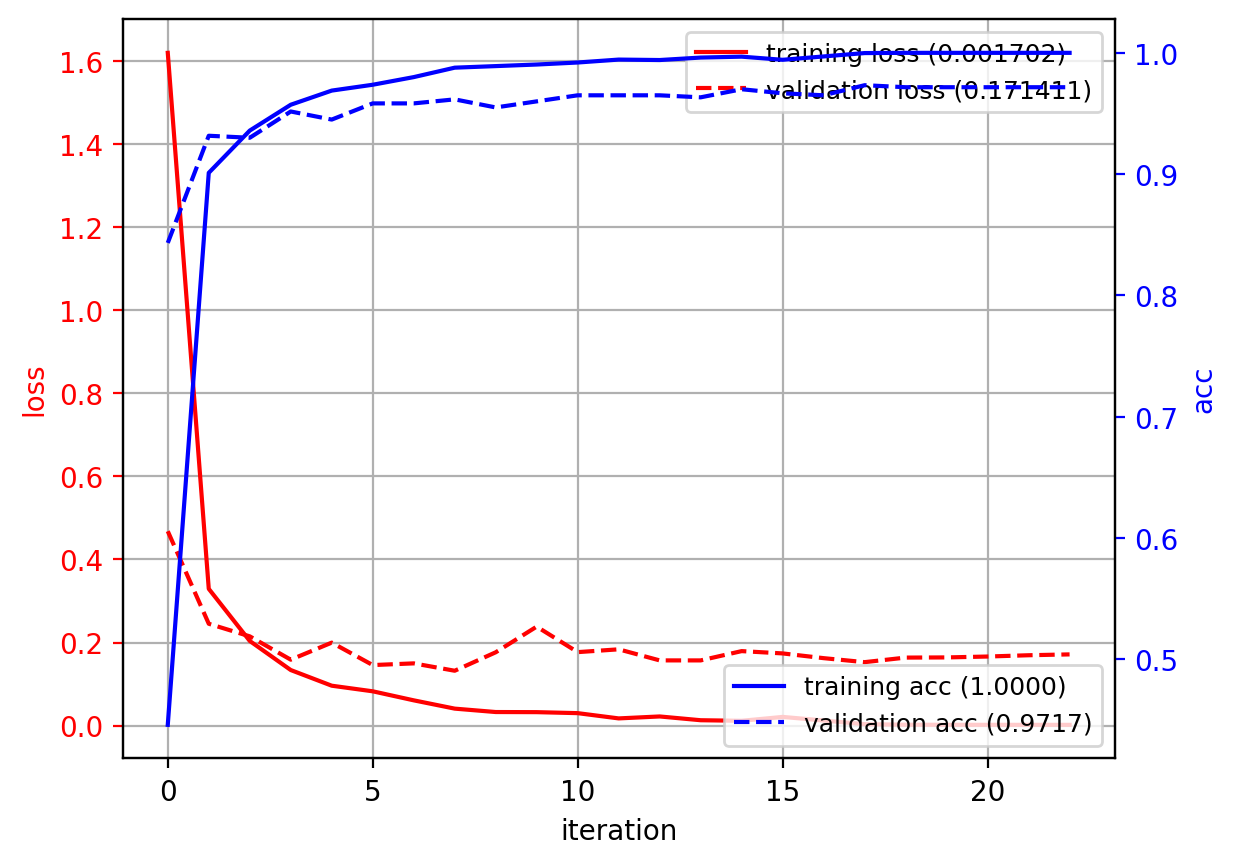

In [13]:
# Initialize random seed
torch.manual_seed(4487)
random.seed(4487)
np.random.seed(4487)
if torch.cuda.is_available():
    torch.cuda.manual_seed(4487)
    torch.backends.cudnn.deterministic = True

# Create model instance
model = CNNWithL2()

# Print model architecture
print(model)
summarize_layer_parameters(model)

# Move model to device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Using device: {device}")


# Prepare data - ensure correct shape for PyTorch (channel first)
# Assuming vtrainI, vtrainY, validI, validY are already defined as in previous cells

# Convert from (batch, height, width, channels) to (batch, channels, height, width)
if len(vtrainI.shape) == 4 and vtrainI.shape[-1] == 1:  # If shape is (N, 28, 28, 1)
    vtrainI = vtrainI.transpose(0, 3, 1, 2)
    validI = validI.transpose(0, 3, 1, 2)

# Create DataLoaders
batch_size = 50
train_dataset = TensorDataset(vtrainI, vtrainY)
valid_dataset = TensorDataset(validI, validY)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)

# Compile the network (equivalent in PyTorch)
criterion = nn.CrossEntropyLoss()  # This includes softmax + cross entropy
optimizer = optim.SGD(model.parameters(), lr=0.02, momentum=0.9, nesterov=True)

# Train the model
history, model = train_model(model, train_loader, valid_loader, criterion, optimizer, epochs=100, writer='runs/l2reg')

# Plot the training history
plot_history(history)

In [14]:
test_dataset = TensorDataset(testI, torch.from_numpy(testY).long())
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
acc = evaluate_model(model, test_loader)

print("test accuracy:", acc)

test accuracy: 96.58


# Which layers should we apply L2 regularization?
- Consider the following network: $f(\mathbf{x}) = \mathbf{A}^T r( \mathbf{B}^T \mathbf{x})$
   - $r(\cdot)$ is the ReLU activation.
- Consider the scaling value $\epsilon>0$:
  $$f(\mathbf{x}) = \mathbf{A}^T r( \mathbf{B}^T \mathbf{x}) = \mathbf{A}^T r( \frac{\epsilon}{\epsilon}\mathbf{B}^T \mathbf{x}) = \frac{1}{\epsilon}\mathbf{A}^T r( \epsilon\mathbf{B}^T \mathbf{x})$$
  - the last line is because for $b>0$, $r(b a) = \max(0,b a) = b \max(0,a)$


- If we decrease $\mathbf{B}$ by $\epsilon<1$, we can increase $\mathbf{A}$ correspondingly to create the same network (with the same loss $L$).
  - $\mathbf{B} \rightarrow \epsilon \mathbf{B}$
  - $\mathbf{A} \rightarrow \frac{1}{\epsilon} \mathbf{B}$
- Thus, when applying L2 regularization on only one layer (e.g., $\mathbf{B}$), the other layer (e.g., $\mathbf{A}$) can be adjusted to get the same network.
  - The L2-norm is artificially reduced without changing the network function.
  - i.e., it has no actual effect.


- **Answer**: apply L2 regularization to *all* layers!

# Overfitting
- occurs when validation curve starts to increase
  - network is specializing only on  the training data, losing generalization ability.

In [15]:
model = CNN() 

print(model)

# Move model to device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Using device: {device}")

optimizer = optim.SGD(model.parameters(), lr=0.02, momentum=0.9, nesterov=True)

# Train the model
history, model = train_model(model, train_loader, valid_loader, criterion, optimizer, epochs=100, patience=-1, writer='runs/overfit')

CNN(
  (conv1): Conv2d(1, 10, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (conv2): Conv2d(10, 40, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (conv3): Conv2d(40, 80, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (fc1): Linear(in_features=3920, out_features=50, bias=True)
  (fc2): Linear(in_features=50, out_features=10, bias=True)
  (relu): ReLU()
  (softmax): Softmax(dim=1)
)
Using device: cuda
Epoch 1/100:   Train Loss: 1.681100, Train Acc: 45.15%;   Val Loss: 0.422775, Val Acc: 86.50%
Epoch 2/100:   Train Loss: 0.326791, Train Acc: 90.52%;   Val Loss: 0.228414, Val Acc: 92.83%
Epoch 3/100:   Train Loss: 0.204111, Train Acc: 93.91%;   Val Loss: 0.165633, Val Acc: 95.33%
Epoch 4/100:   Train Loss: 0.131937, Train Acc: 95.72%;   Val Loss: 0.189064, Val Acc: 94.50%
Epoch 5/100:   Train Loss: 0.099432, Train Acc: 96.96%;   Val Loss: 0.140649, Val Acc: 95.67%
Epoch 6/100:   Train Loss: 0.072953, Train Acc: 97.65%;   Val Loss: 0.131709, Val Acc: 97.00%
Epoch 7/100: 

# Early Stopping
- Stopping training when the validation loss increases
  - equivalently, selecting the model/iteration with lowest validation loss.

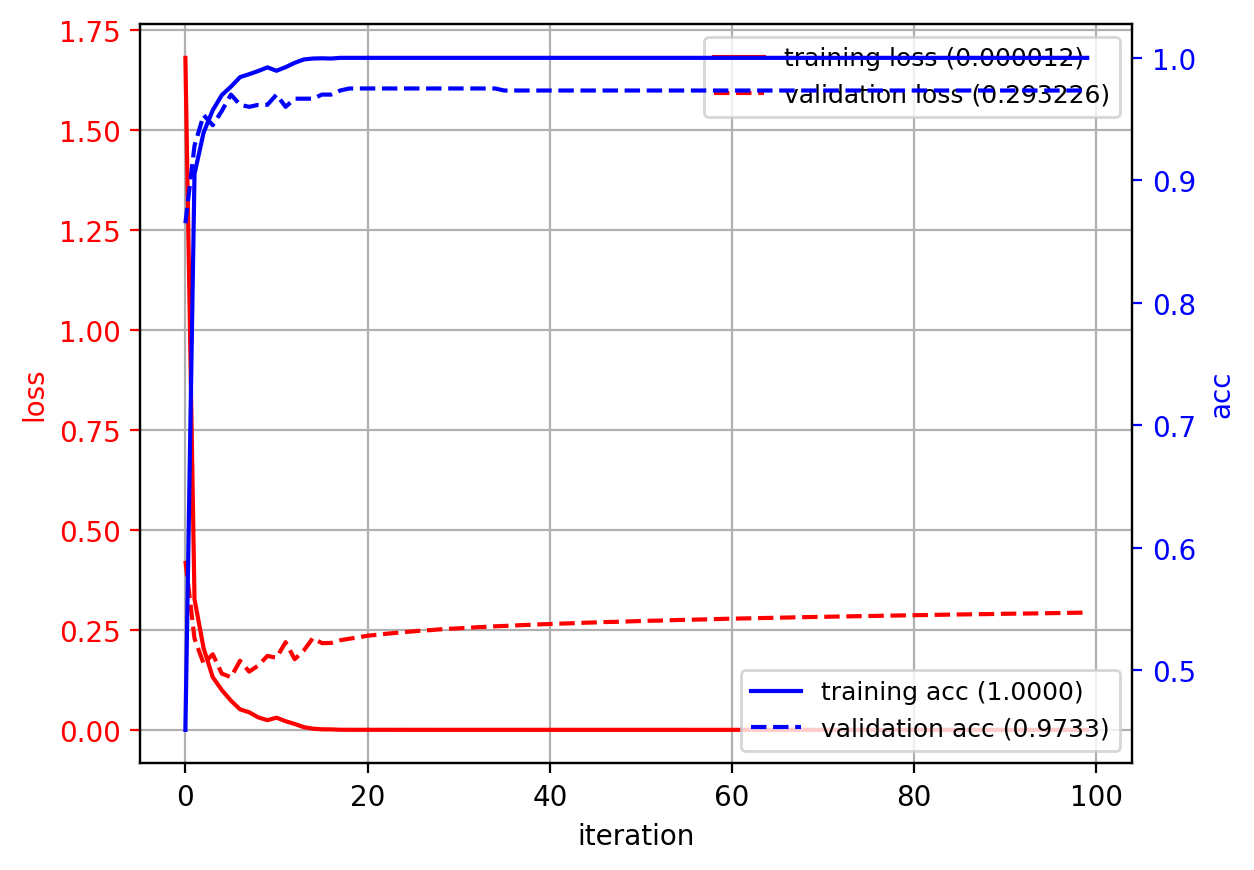

In [16]:
# Plot the training history
plot_history(history)

# Early Stopping as Regularization
- Early stopping is a form of regularization
  - limit the number of training iterations = limiting how far parameters $\mathbf{w}$ can move.
    - e.g., if we initialize $\mathbf{w}=0$, then early stopping limits the L2-norm of $\mathbf{w}$.
  - the amount $\mathbf{w}$ can move is adaptive to the data via the validation loss.
  
<center><img src="imgs/earlystop.png" width=400></center>

# Improving Generalization with Ensembles
- **Bagging**: Bootstrap Aggregation
  - combine predictions from several models (model averaging).
- Suppose we have $K$ models, each model has error $\epsilon_i$
  - MSE of each model: $\mathrm{MSE}_i = \mathbb{E}[\epsilon_i^2] = V$
- Combining the models:
  - MSE of the combined model: $\mathrm{MSE}_c = \frac{V}{K} + \frac{K-1}{K} C$
    - $C=\mathbb{E}[\epsilon_i \epsilon_j]$ is the correlation between errors of the i-th and j-th models.
- If the errors are uncorrelated ($C=0$), then the MSE decreases!
  - $\mathrm{MSE}_c = \frac{V}{K}$

# Bagging for NN
- Typically bagging needs to create a new dataset by sampling with replacement of the original dataset, and then learning a new model on each generated dataset.
- For NN, there are enough solution points
  - we can use the same dataset, and different initializations (or change hyperparameters).
  - this should give models with partially uncorrelated errors.
- This is a **very** popular way to boost performance.

In [17]:
# Initialize random seed
torch.manual_seed(4487)
random.seed(4487)
np.random.seed(4487)
if torch.cuda.is_available():
    torch.cuda.manual_seed(4487)
    torch.backends.cudnn.deterministic = True

allnn = []
allhistory = []
for bag in range(5):

    model = CNNWithL2() 
    
    # Move model to device (GPU if available)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    print(f"Using device: {device}")
    
    optimizer = optim.SGD(model.parameters(), lr=0.02, momentum=0.9, nesterov=True)
    history, model = train_model(model, train_loader, valid_loader, criterion, optimizer, epochs=100)

    allnn.append(model)
    allhistory.append(history)

Using device: cuda
Epoch 1/100:   Train Loss: 1.620371, Train Acc: 44.61%;   Val Loss: 0.468100, Val Acc: 84.33%
Epoch 2/100:   Train Loss: 0.329343, Train Acc: 90.11%;   Val Loss: 0.245200, Val Acc: 93.17%
Epoch 3/100:   Train Loss: 0.203770, Train Acc: 93.59%;   Val Loss: 0.214860, Val Acc: 93.00%
EarlyStopping counter: 1 out of 5
Epoch 4/100:   Train Loss: 0.133710, Train Acc: 95.72%;   Val Loss: 0.158682, Val Acc: 95.17%
Epoch 5/100:   Train Loss: 0.095974, Train Acc: 96.89%;   Val Loss: 0.199730, Val Acc: 94.50%
EarlyStopping counter: 1 out of 5
Epoch 6/100:   Train Loss: 0.082481, Train Acc: 97.37%;   Val Loss: 0.145677, Val Acc: 95.83%
Epoch 7/100:   Train Loss: 0.060736, Train Acc: 98.00%;   Val Loss: 0.149765, Val Acc: 95.83%
EarlyStopping counter: 1 out of 5
Epoch 8/100:   Train Loss: 0.040754, Train Acc: 98.78%;   Val Loss: 0.132005, Val Acc: 96.17%
Epoch 9/100:   Train Loss: 0.032565, Train Acc: 98.91%;   Val Loss: 0.176460, Val Acc: 95.50%
EarlyStopping counter: 1 out of 5

# Example: Ensembles
- train 5 CNNs with same architectures but different initializations

In [18]:
import pdb
def ensemble_prediction(models, eval_loader):
    num_models = len(models)
    eval_correct = {i:0 for i in range(num_models+1)}
    eval_total = {i:0 for i in range(num_models+1)}
    allpred = {i:[] for i in range(num_models+1)}
    
    with torch.no_grad():
        for data, target in eval_loader:
            data = data.to(device)
            outputs = []
            for i,model in enumerate(models):
                model.eval()
                output = model(data)
                _, predicted = torch.max(output.data, 1)
                predicted = predicted.cpu()
                eval_total[i] += target.size(0)
                eval_correct[i] += (predicted == target).sum().item()
                allpred[i].append(predicted.numpy())
                outputs.append(output.cpu())
            eval_total[num_models] += target.size(0)
            _, predicted = torch.max(torch.stack(outputs,dim=-1).sum(dim=-1).data, 1)
            allpred[num_models].append(predicted.numpy())
            eval_correct[num_models] += (predicted == target).sum().item()

    eval_accuracy = {i:100 * eval_correct[i] / eval_total[i] for i in range(num_models+1)}
    return eval_accuracy, allpred

In [19]:
eval_accuracy, allpred = ensemble_prediction(allnn, test_loader)

- various errors for the individual NNs
- ensembling the predictions improves accuracy

In [20]:
# compute error for individual models
for i,acc in eval_accuracy.items():
    if i < len(allnn):
        print("model {} test accuracy: {}".format(i, acc))

# compute error for ensemble
print("combined model test accuracy: {}".format(eval_accuracy[len(allnn)]))

model 0 test accuracy: 96.58
model 1 test accuracy: 95.81
model 2 test accuracy: 96.18
model 3 test accuracy: 96.12
model 4 test accuracy: 95.89
combined model test accuracy: 96.65


# Dropout
- **Problem:** training a large number of NNs for an ensemble is time consuming.
- **Goal:** approximate a really large ensemble of models
  - create an ensemble by randomly removing an input/hidden node with some probability.
<center><img src="imgs/dropoutensemble.png" width=400></center>

- number of models is exponential in the number of nodes.
- share the same parameters for each sub-model.
  - we can train all models in the ensemble at the same time.

# Dropout  Training
- During training, randomly "drop out" each node with probability $p$
  - a dropped-out node is not used for calculating the prediction or weight updating.
  - trains a reduced network in each iteration.

<center><img src="imgs/dropout.jpeg" width=500></center>

- During test time, use all the nodes for prediction and scale output by $1-p$.
  - this keeps the expected value of the node to be the same as during training.
  - analogous to computing predictions from all models, and then averages the predictions.



- Dropout is implemented as a layer.
- Example: 
  - apply dropout layer after last feature layer and 1st dense layer.

In [21]:
class CNNWithDropout(CNN):
    def __init__(self):
        super(CNNWithDropout, self).__init__()
        self.drop1d = nn.Dropout(p=0.5)
        self.drop2d = nn.Dropout2d(p=0.5)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.relu(self.conv3(x))
        x = self.drop2d(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.relu(self.fc1(x))
        x = self.fc2(self.drop1d(x))
        return x

CNNWithDropout(
  (conv1): Conv2d(1, 10, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (conv2): Conv2d(10, 40, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (conv3): Conv2d(40, 80, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (fc1): Linear(in_features=3920, out_features=50, bias=True)
  (fc2): Linear(in_features=50, out_features=10, bias=True)
  (relu): ReLU()
  (softmax): Softmax(dim=1)
  (drop1d): Dropout(p=0.5, inplace=False)
  (drop2d): Dropout2d(p=0.5, inplace=False)
)
Using device: cuda
Epoch 1/100:   Train Loss: 1.856782, Train Acc: 33.48%;   Val Loss: 0.622844, Val Acc: 80.83%
Epoch 2/100:   Train Loss: 0.708875, Train Acc: 77.61%;   Val Loss: 0.295382, Val Acc: 91.33%
Epoch 3/100:   Train Loss: 0.478177, Train Acc: 85.39%;   Val Loss: 0.225654, Val Acc: 93.67%
Epoch 4/100:   Train Loss: 0.368947, Train Acc: 89.13%;   Val Loss: 0.160814, Val Acc: 95.50%
Epoch 5/100:   Train Loss: 0.310231, Train Acc: 90.54%;   Val Loss: 0.130448, Val Acc: 96.17%
Epoch 6/10

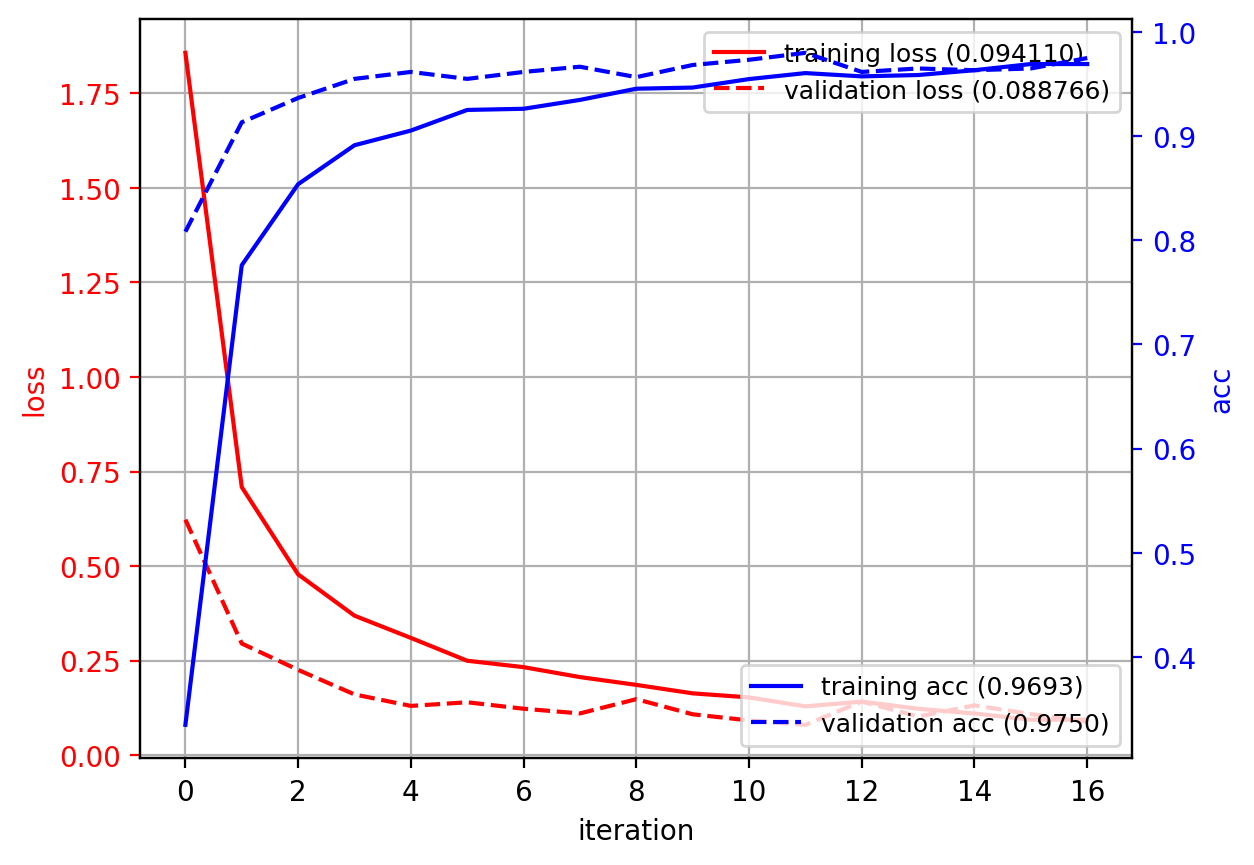

In [22]:
model = CNNWithDropout() 

# Print model architecture
print(model)

# Move model to device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Using device: {device}")

optimizer = optim.SGD(model.parameters(), lr=0.02, momentum=0.9, nesterov=True)

# Train the model
history, model = train_model(model, train_loader, valid_loader, criterion, optimizer, epochs=100, writer='runs/dropout')

# Plot the training history
plot_history(history)

  - accuracy improves

In [23]:
acc = evaluate_model(model, test_loader)
print("test accuracy:", acc)

test accuracy: 96.77


# Effects of Dropout
- dropping a node means the node's output is 0
  - i.e., the gradient is 0, which blocks some paths when computing gradients.
  - helps with vanishing gradient problem
- model averaging reduces the error.
- Dropout *reduces* the effective capacity of the network.
  - may need to increase the model size.
- At any  time  a node $h$ will be removed, i.e., that feature is missing.
  - then the other features must be sufficient to solve the classification problem
  - classifier doesn't depend exclusively on one feature.
  - increases classifier robustness.

# Data augmentation
- Problem: not enough data
- Solution: artificially permute the data to increase the dataset size
  - goal: make the network invariant to the permutations
  - examples: translate image, flip image, add pixel noise, rotate image, deform image, etc.
<center><img src="imgs/dogs.png" width=500></center>

In [24]:
# build the data augmenter

transform_train = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomRotation(degrees=10),                    # rotation_range=10
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)), # width_shift_range=0.1, height_shift_range=0.1
    transforms.RandomAffine(degrees=0, shear=10),             # shear_range=0.1
    transforms.RandomResizedCrop(28, scale=(0.9, 1.1)),      # zoom_range=0.1
    transforms.ToTensor()
])

class MyDataset(Dataset):
    def __init__(self, imgs, labels, transform=None):
        super(MyDataset, self).__init__()
        self.transform = transform
        self.imgs = imgs
        self.labels = labels

    def __getitem__(self, item):
        img = self.transform(self.imgs[item])
        target = self.labels[item]
        return img, target

    def __len__(self):
        return len(self.labels)

In [25]:
train_aug_dataset = MyDataset(vtrainI,vtrainY,transform_train)
imgs = []

cnt = 0
for augx, y in train_aug_dataset:
    imgs.append(augx[0].numpy())
    cnt += 1
    if cnt > 8:
        # we need to break the loop by hand because
        # the generator loops indefinitely
        break

- Example of original (top-left) and augmented data

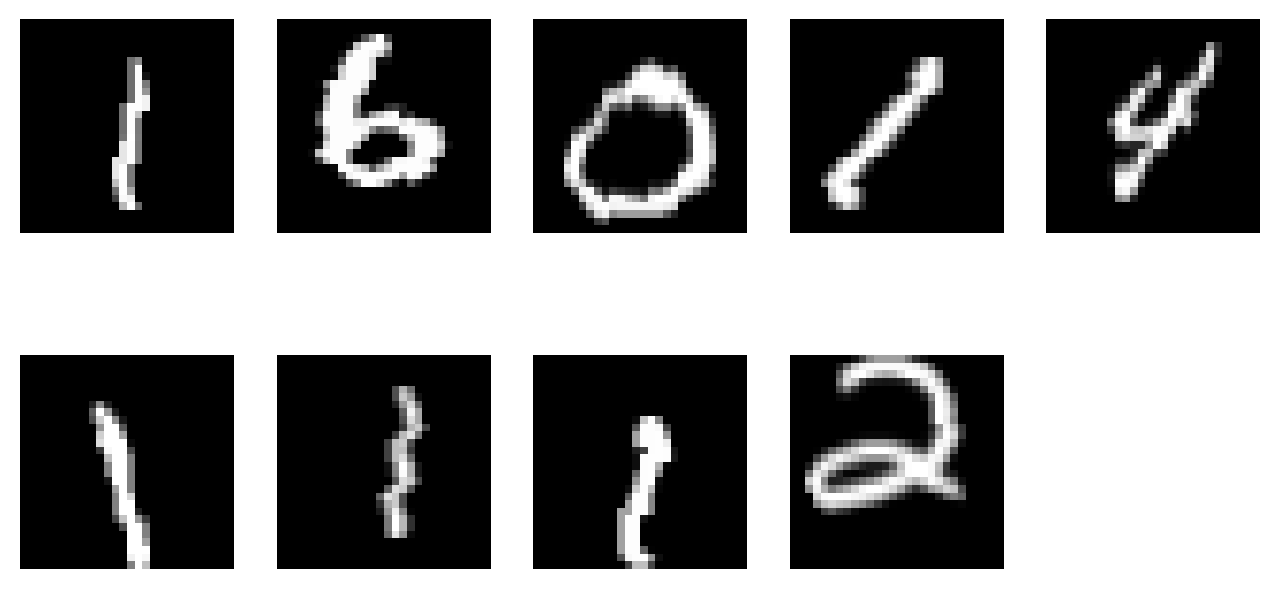

In [26]:
plt.figure(figsize=(8,4))
show_imgs(imgs, nc=5)
plt.show()

- Any transformation is okay, as long as the transformation doesn't confuse the classes.
  - e.g. don't rotate "6" so that it looks like a "9"
- Data augmentation improves robustness or invariance to selected transformations
  - encoded in the parameters of the model.

CNNWithDropout(
  (conv1): Conv2d(1, 10, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (conv2): Conv2d(10, 40, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (conv3): Conv2d(40, 80, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (fc1): Linear(in_features=3920, out_features=50, bias=True)
  (fc2): Linear(in_features=50, out_features=10, bias=True)
  (relu): ReLU()
  (softmax): Softmax(dim=1)
  (drop1d): Dropout(p=0.5, inplace=False)
  (drop2d): Dropout2d(p=0.5, inplace=False)
)
Using device: cuda
Epoch 1/100:   Train Loss: 2.297832, Train Acc: 12.09%;   Val Loss: 2.258782, Val Acc: 21.00%
Epoch 2/100:   Train Loss: 1.757125, Train Acc: 37.43%;   Val Loss: 0.814421, Val Acc: 79.17%
Epoch 3/100:   Train Loss: 1.132176, Train Acc: 61.96%;   Val Loss: 0.517821, Val Acc: 86.33%
Epoch 4/100:   Train Loss: 0.827414, Train Acc: 72.19%;   Val Loss: 0.297796, Val Acc: 91.17%
Epoch 5/100:   Train Loss: 0.683318, Train Acc: 78.74%;   Val Loss: 0.229370, Val Acc: 93.50%
Epoch 6/10

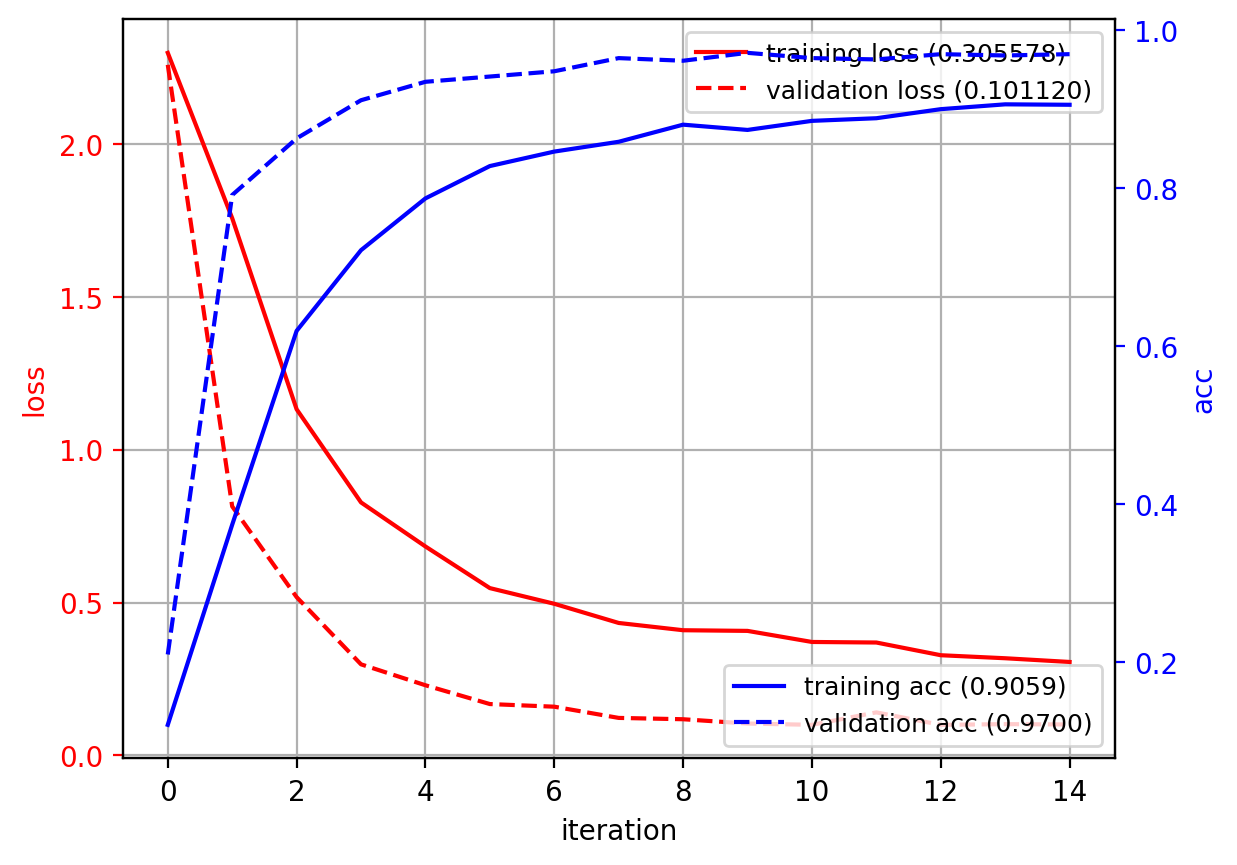

In [27]:
model = CNNWithDropout() 

# Print model architecture
print(model)

# Move model to device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Using device: {device}")

optimizer = optim.SGD(model.parameters(), lr=0.02, momentum=0.9, nesterov=True)

train_aug_loader = DataLoader(train_aug_dataset, batch_size=batch_size, shuffle=True)

# Train the model
history, model = train_model(model, train_aug_loader, valid_loader, criterion, optimizer, epochs=100, writer='runs/daug')

# Plot the training history
plot_history(history)

- Model Training
  - passes data through the customized dataset first
  - runs dataloader as data generator and fit in parallel
- the dataset changes each epoch, so validation error will change a lot.
  - we disable early stopping and just let it run for 100 epochs.
- use TensorBoard to view the current results in real-time.
  - Create a `TensorBoard` object and use it as the callback.
  - This will write the history information to the logs directory.

CNNWithDropout(
  (conv1): Conv2d(1, 10, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (conv2): Conv2d(10, 40, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (conv3): Conv2d(40, 80, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (fc1): Linear(in_features=3920, out_features=50, bias=True)
  (fc2): Linear(in_features=50, out_features=10, bias=True)
  (relu): ReLU()
  (softmax): Softmax(dim=1)
  (drop1d): Dropout(p=0.5, inplace=False)
  (drop2d): Dropout2d(p=0.5, inplace=False)
)
Using device: cuda
Epoch 1/100:   Train Loss: 2.175980, Train Acc: 20.35%;   Val Loss: 1.243000, Val Acc: 62.17%
Epoch 2/100:   Train Loss: 1.339405, Train Acc: 54.20%;   Val Loss: 0.482699, Val Acc: 87.17%
Epoch 3/100:   Train Loss: 0.907097, Train Acc: 69.56%;   Val Loss: 0.293861, Val Acc: 90.33%
Epoch 4/100:   Train Loss: 0.681126, Train Acc: 78.33%;   Val Loss: 0.218618, Val Acc: 94.00%
Epoch 5/100:   Train Loss: 0.594205, Train Acc: 81.57%;   Val Loss: 0.194515, Val Acc: 95.00%
Epoch 6/10

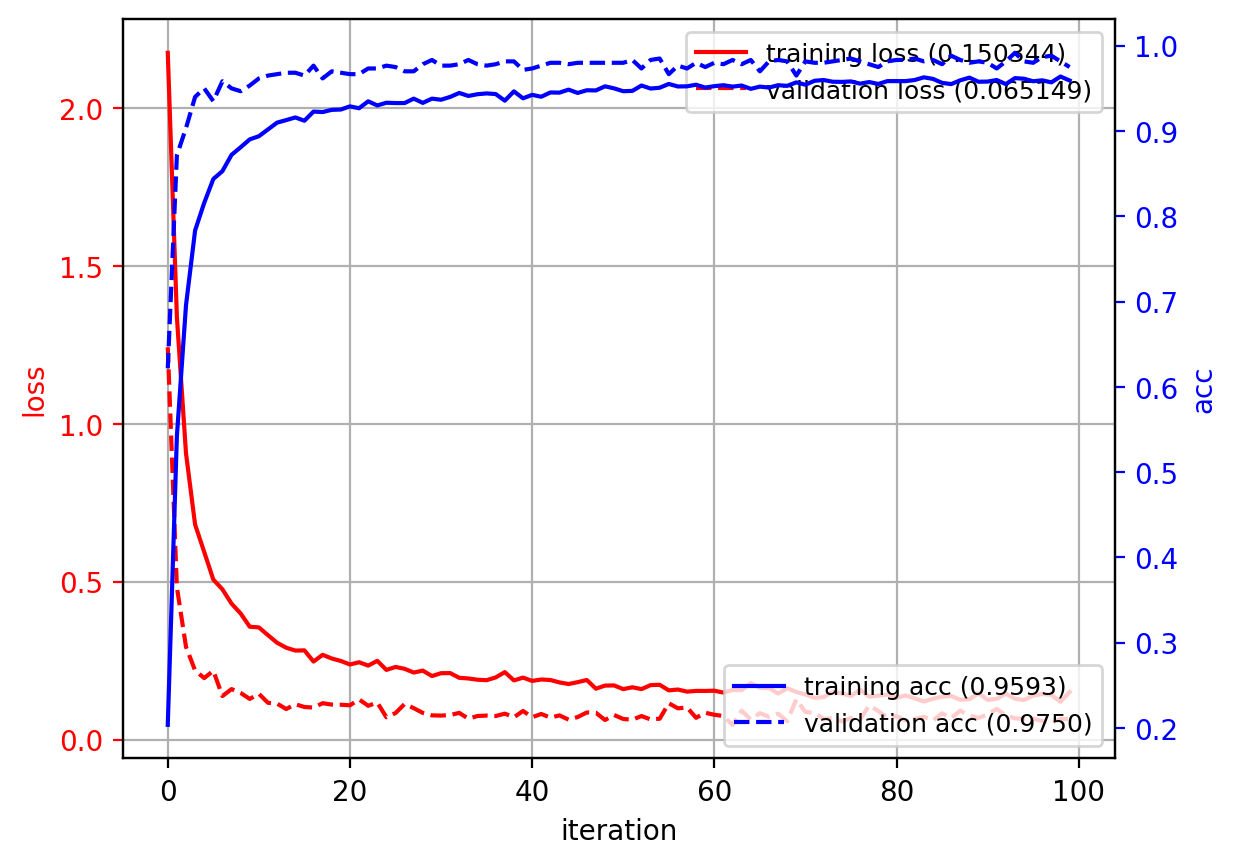

In [28]:
model = CNNWithDropout() 

# Print model architecture
print(model)

# Move model to device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Using device: {device}")

optimizer = optim.SGD(model.parameters(), lr=0.02, momentum=0.9, nesterov=True)

# Train the model
history, model = train_model(model, train_aug_loader, valid_loader, criterion, optimizer, epochs=100, patience=-1, writer='runs/daug-100')

# Plot the training history
plot_history(history)

# Tensorboard
- Tensorboard runs as a local webserver to view the results in the log directory.
  - to start Tensorboard, run the following command in the shell: `tensorboard --logdir ./logs`
  - then connect to the local webserver using a browser (the URL is printed out when Tensorboard starts).

<center><img src="imgs/tensorboard.png" width=800></center>


- data augmentation increases accuracy.

In [29]:
acc = evaluate_model(model, test_loader)
print("test accuracy:", acc)

test accuracy: 98.57


# Data augmentation with noise
- Also add per-pixel noise to the image for data augmentation.
  - define a function to add noise
  - set it as the `preprocessing_function`

In [30]:
transform_noise = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomRotation(degrees=10),                    # rotation_range=10
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)), # width_shift_range=0.1, height_shift_range=0.1
    transforms.RandomAffine(degrees=0, shear=10),             # shear_range=0.1
    transforms.RandomResizedCrop(28, scale=(0.9, 1.1)),      # zoom_range=0.1
    transforms.ToTensor(),
    transforms.Lambda(lambda x: torch.clamp(x + torch.randn_like(x) * np.sqrt(0.05), 0, 1)),
])

train_noise_dataset = MyDataset(vtrainI,vtrainY,transform_noise)

- Example: original image (top-left) and augmented data

In [31]:
imgs = []

cnt = 0
for augx, y in train_noise_dataset:
    imgs.append(augx[0].numpy())
    cnt += 1
    if cnt > 8:
        # we need to break the loop by hand because
        # the generator loops indefinitely
        break

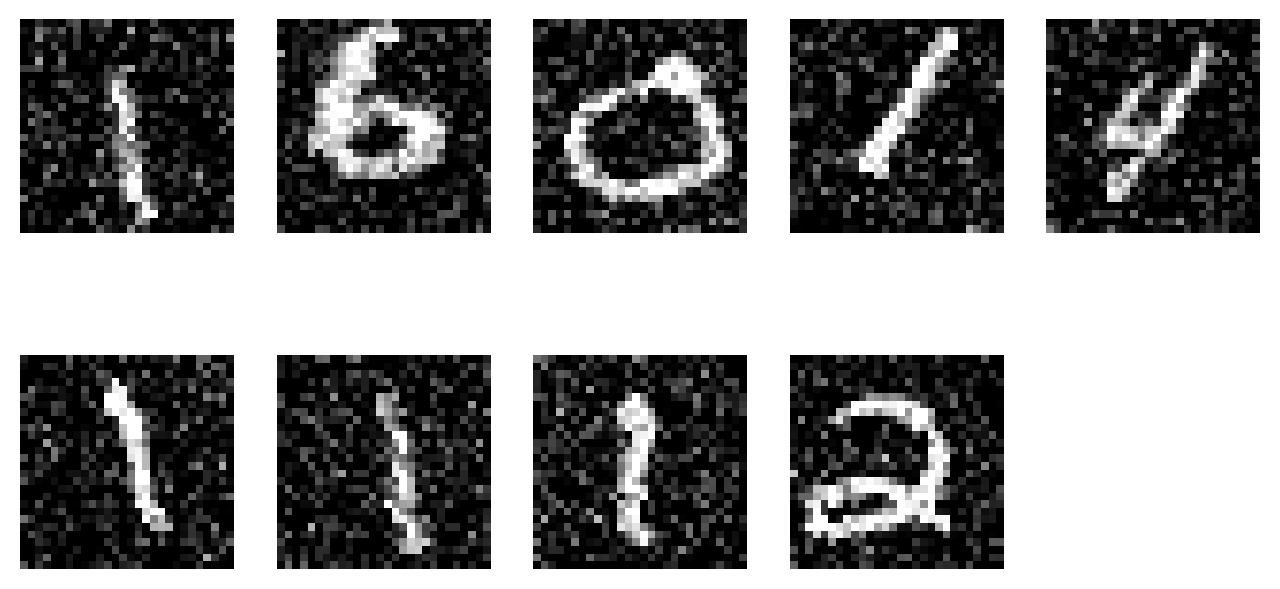

In [32]:
plt.figure(figsize=(8,4))
show_imgs(imgs, nc=5)
plt.show()

- Train with augmented data: transformations and per-pixel noise

CNNWithDropout(
  (conv1): Conv2d(1, 10, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (conv2): Conv2d(10, 40, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (conv3): Conv2d(40, 80, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (fc1): Linear(in_features=3920, out_features=50, bias=True)
  (fc2): Linear(in_features=50, out_features=10, bias=True)
  (relu): ReLU()
  (softmax): Softmax(dim=1)
  (drop1d): Dropout(p=0.5, inplace=False)
  (drop2d): Dropout2d(p=0.5, inplace=False)
)
Using device: cuda
Epoch 1/100:   Train Loss: 2.291393, Train Acc: 12.98%;   Val Loss: 2.155801, Val Acc: 35.50%
Epoch 2/100:   Train Loss: 1.689179, Train Acc: 42.02%;   Val Loss: 0.836176, Val Acc: 76.00%
Epoch 3/100:   Train Loss: 1.131734, Train Acc: 61.33%;   Val Loss: 0.421438, Val Acc: 87.50%
Epoch 4/100:   Train Loss: 0.841336, Train Acc: 72.65%;   Val Loss: 0.319056, Val Acc: 90.67%
Epoch 5/100:   Train Loss: 0.677139, Train Acc: 78.31%;   Val Loss: 0.276410, Val Acc: 92.17%
Epoch 6/10

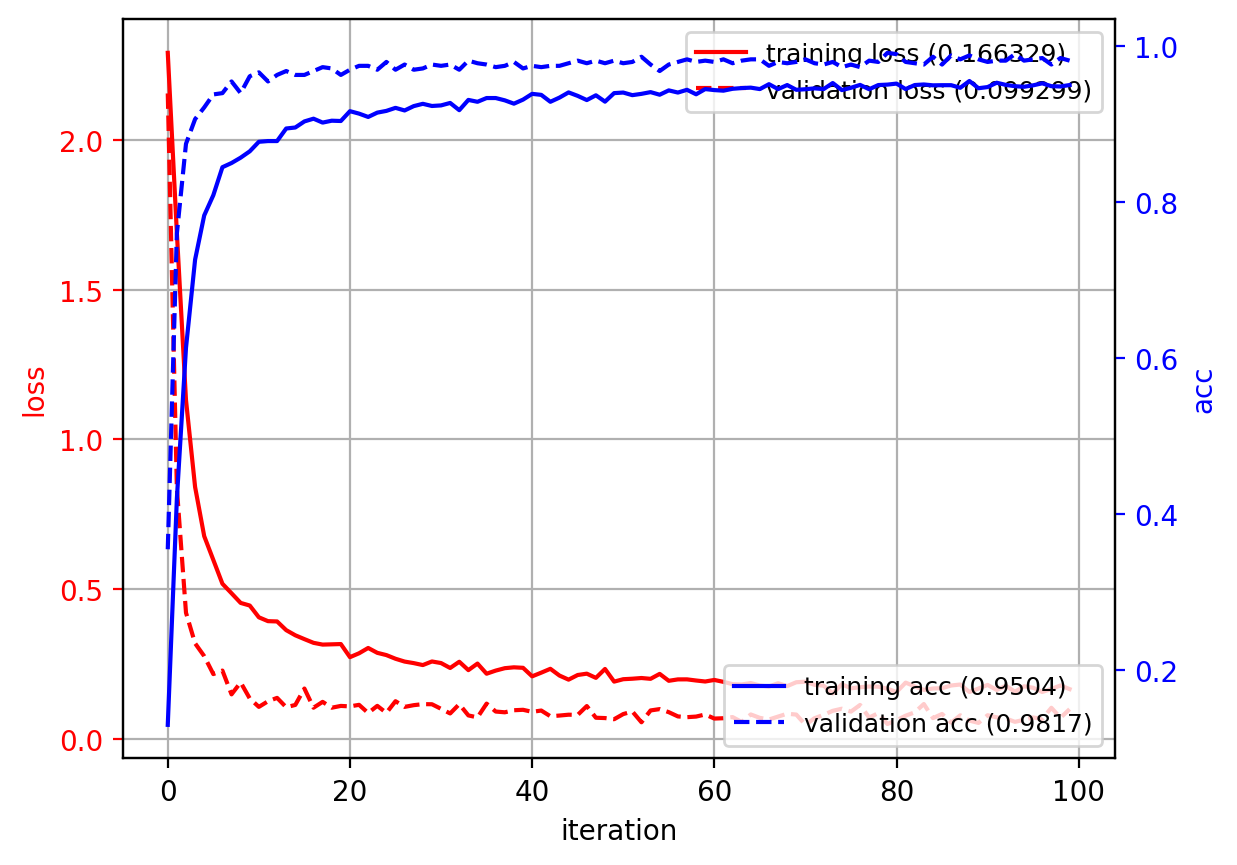

In [33]:
model = CNNWithDropout() 

# Print model architecture
print(model)

# Move model to device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
print(f"Using device: {device}")

train_noise_loader = DataLoader(train_noise_dataset, batch_size=batch_size, shuffle=True)

optimizer = optim.SGD(model.parameters(), lr=0.02, momentum=0.9, nesterov=True)

# Train the model
history, model = train_model(model, train_noise_loader, valid_loader, criterion, optimizer, epochs=100, patience=-1, writer='runs/daug-noise')

# Plot the training history
plot_history(history)

- Similar results.

In [34]:
acc = evaluate_model(model, test_loader)
print("test accuracy:", acc)

test accuracy: 98.75


# Data generator options
- Sometimes the dataset is too large to store completely in RAM:
  - keep the path as `text` and iterate over paths to read images in a directory


# Comparison on MNIST
- For image data, CNN works better and has less parameters.
<table style="font-size:10pt;">
<tr>
  <th>Type</th>
  <th>No.Layers</th>
  <th>Architecture</th>
  <th>No.Parameters</th>
  <th>Test Accuracy</th>
</tr><tr>
  <td>LR</td>
  <td>1</td>
  <td>output(10)</td>
  <td>7,850</td>
  <td>0.8911</td>
</tr><tr>
  <td>MLP</td>
  <td>2</td>
  <td>ReLu(50), output(10)</td>
  <td>39,760</td>
  <td>0.9380</td>
</tr><tr>
  <td>MLP</td>
  <td>2</td>
  <td>Relu(200), output(10)</td>
  <td>159,010</td>
  <td>0.9437</td>
</tr><tr>
  <td>MLP</td>
  <td>2</td>
  <td>Relu(1000), output(10)</td>
  <td>795,010</td>
  <td>0.9462</td>
</tr><tr>
  <td>MLP</td>
  <td>3</td>
  <td>ReLu(500), Relu(500), output(10)</td>
  <td>648,010</td>
  <td>0.9529</td>
</tr><tr>
  <td>CNN</td>
  <td>3</td>
  <td>Conv(10x5x5), ReLu(50), output(10)</td>
  <td>98,820</td>
  <td>0.9534</td>
</tr><tr>
  <td>CNN</td>
  <td>5</td>
  <td>Conv(10x5x5), Conv(50x3x3), Conv(80x3x3), ReLu(50), output(10)</td>
  <td>286,940</td>
  <td>0.9564</td>
</tr><tr>
  <td>CNN (w/ weight decay)</td>
  <td>5</td>
  <td>Conv(10x5x5), Conv(50x3x3), Conv(80x3x3), ReLu(50), output(10)</td>
  <td>286,940</td>
  <td>0.9660</td>
</tr><tr>
  <td>CNN (ensemble)</td>
  <td>5</td>
  <td>Conv(10x5x5), Conv(50x3x3), Conv(80x3x3), ReLu(50), output(10)</td>
  <td>5x286,940</td>
  <td>0.9723</td>
</tr><tr>
  <td>CNN (w/ dropout)</td>
  <td>5</td>
  <td>Conv(10x5x5), Conv(50x3x3), Conv(80x3x3), ReLu(50), output(10)</td>
  <td>286,940</td>
  <td>0.9713</td>
</tr><tr>
  <td>CNN (w/ dropout, data-augmentation)</td>
  <td>5</td>
  <td>Conv(10x5x5), Conv(50x3x3), Conv(80x3x3), ReLu(50), output(10)</td>
  <td>286,940</td>
  <td>0.9893</td>
</tr><tr>
  <td>CNN (w/ dropout, data-augmentation, noise)</td>
  <td>5</td>
  <td>Conv(10x5x5), Conv(50x3x3), Conv(80x3x3), ReLu(50), output(10)</td>
  <td>286,940</td>
  <td>0.9895</td>
</tr>
</table>

# Summary
- **Convolutional neural network (CNN)**
  - convolution filters for extracting local image features
     - global translation equivariance 
  - local translation invariance using max-pooling
  - classifier using MLP on the image features.
- **Regularization methods**
  - L2-norm regularization (weight-decay) - keep weights from becoming too large
  - Early-stopping - adaptively keep weights from becoming too large
  - Ensembles - reduce error by bagging
  - Dropout  - approximate an ensemble of networks
  - Data Augmentation - make the NN robust to various image transformations